# Predicting Heart Disease using Machine Learning

This notebook will introduce some foundation machine learning and data science concepts by exploring the problem of heart disease **classification**.

For example, given a person's health characteristics, we're going to build a model to predict whether or not they have heart disease.

It is intended to be an end-to-end example of what a data science and machine learning **proof of concept** might look like.

## What is classification?

Classification involves deciding whether a sample is part of one class or another (**binary classification**). 

If there are multiple class options, it's referred to as **multi-class classification**.


## What we'll end up with

We'll start with the heart disease dataset we've worked on in previous modules and we'll approach the problem following the machine learning modelling framework.

| <img src="https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/images/ml101-6-step-ml-framework-tools.png?raw=true" width=500/> | 
|:--:| 
| 6 Step Machine Learning Modelling Framework |

More specifically, we'll look at the following topics.

| Step | What we'll cover |
|:-----|:-----|
| **Exploratory data analysis (EDA)** | The process of going through a dataset and discovering more about it. |
| **Model training**  | Create model(s) to learn to predict a target variable based on other variables. |
| **Model evaluation** | Evaluating a model's predictions using problem-specific evaluation metrics. |
| **Model comparison** | Comparing several different models to find the best one. |
| **Model hyperparameter tuning** | Once we've found a good model, can we tweak its hyperparameters to improve it? |
| **Feature importance** | Since we're predicting the presence of heart disease, are there some features/characteristics that are more important for prediction? |
| **Cross-validation** | If we do build a good model, can we be sure it will work on unseen data? |
| **Reporting what we've found** | If we had to present our work, what would we show someone? |

To work through these topics, we'll use pandas, Matplotlib and NumPy for data anaylsis, as well as, Scikit-Learn for machine learning and modelling tasks.

| <img src="https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/images/supervised-projects-6-step-ml-framework-tools-highlight.png?raw=true" width=750/> | 
|:--:| 
| Tools which can be used for each step of the machine learning modelling process. |

We'll work through each step and by the end of the notebook, we'll have a handful of models, all which can predict whether or not a person has heart disease based on a number of different parameters at a considerable accuracy. 

You'll also be able to describe which parameters are more indicative than others, for example, sex may be more important than age.

## Preparing tools

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

## Model Evaluators
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

# Print versions of libraries we're using (as long as yours are equal or greater than these, your code should work)
print(f"NumPy version: {np.__version__}")
print(f"pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"Scikit-Learn version: {sklearn.__version__}")

NumPy version: 2.4.6
pandas version: 3.0.3
matplotlib version: 3.10.9
Scikit-Learn version: 1.8.0


## Loading Data

In [2]:
df = pd.read_csv("../data/raw/heart-disease.csv")
df.shape

(303, 14)

In [3]:
# check the head of the dataframe
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Data Exploration (EDA)

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [5]:
# let's see how many positive (1) and negative (0) samples we have in the DataFrame
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [6]:
# Normalized value counts
df.target.value_counts(normalize=True) * 100

target
1    54.455446
0    45.544554
Name: proportion, dtype: float64

<Axes: xlabel='target'>

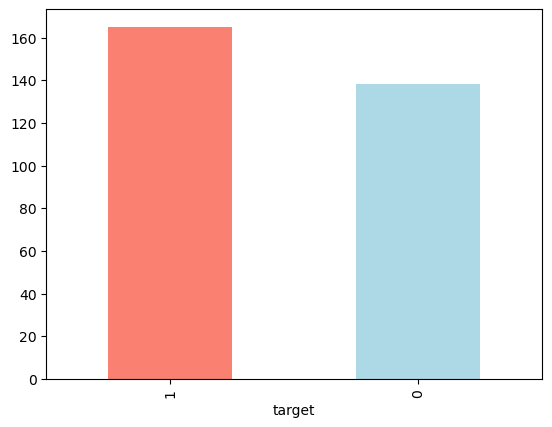

In [7]:
# plot the value counts with a bar graph
df.target.value_counts().plot(kind="bar", color=["salmon", "lightblue"])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [11]:
## Comparing one feature to another
# compare target column with sex column
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


<Axes: xlabel='target'>

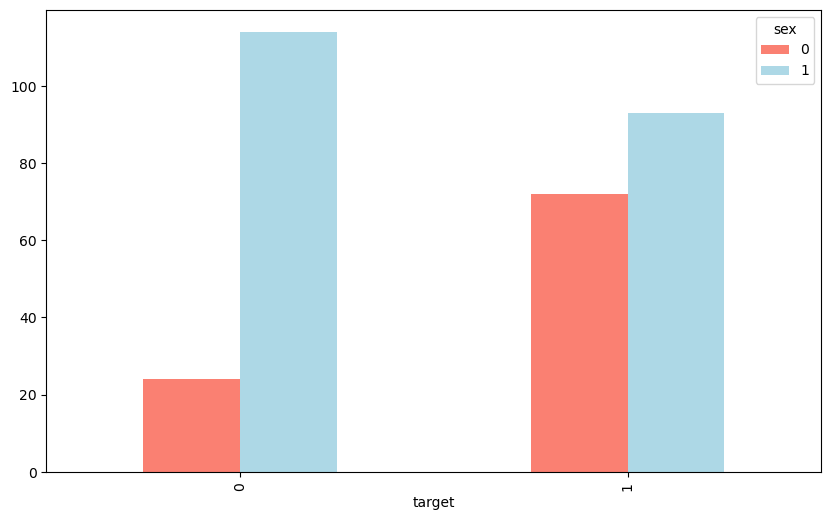

In [12]:
## Making our comparison visual
pd.crosstab(df.target, df.sex).plot(kind="bar", color=["salmon", "lightblue"], figsize=(10, 6))

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

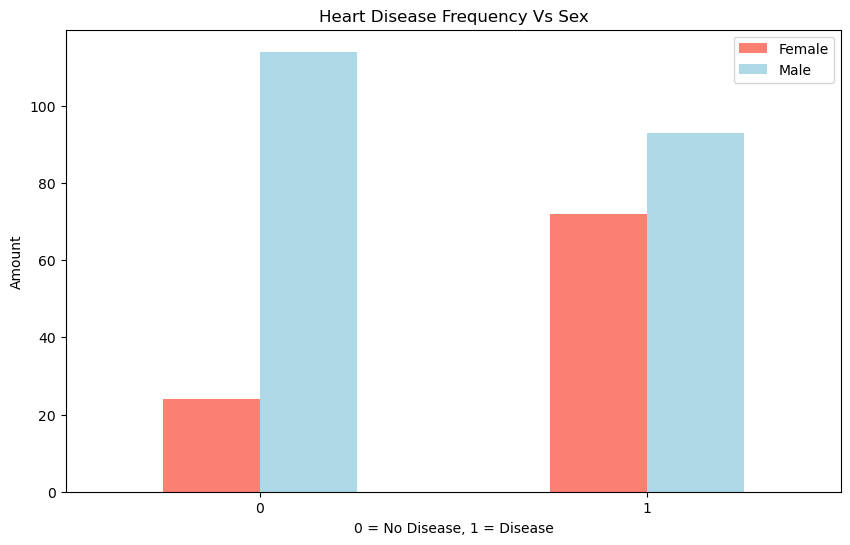

In [13]:
## Add some helpful labels to it
pd.crosstab(df.target, df.sex).plot(kind="bar", color=["salmon", "lightblue"], figsize=(10, 6))

# Add some attributes to it
plt.title("Heart Disease Frequency Vs Sex")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"])
plt.xticks(rotation=0)

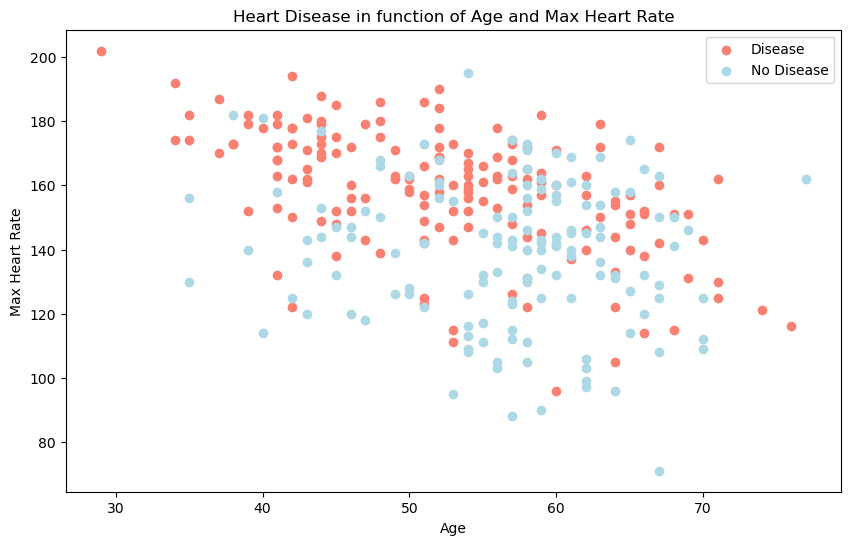

In [14]:
## Comparing age and maximum heart heart rate
plt.figure(figsize=(10, 6))

plt.scatter(df.age[df.target == 1],
           df.thalach[df.target == 1],
           c="salmon")

plt.scatter(df.age[df.target == 0],
           df.thalach[df.target == 0],
           c="lightblue")

plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease", "No Disease"])

<Axes: ylabel='Frequency'>

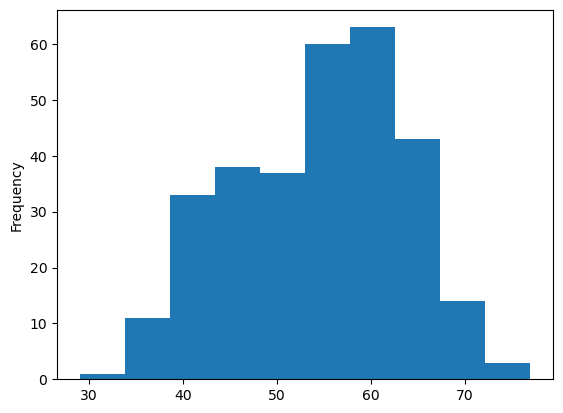

In [15]:
# Histograms
df.age.plot.hist()

In [16]:
## Comparing heart disease frequency and chest pain type
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


In [17]:
df.cp.value_counts()

cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64

(array([0, 1, 2, 3]),
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

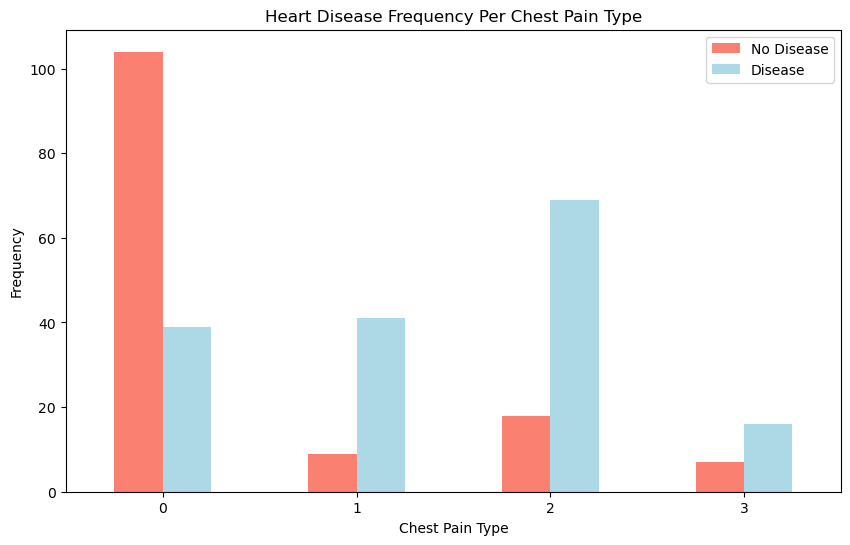

In [18]:
# Create a new crosstab and base plot
pd.crosstab(df.cp, df.target).plot(kind="bar", color=["salmon", "lightblue"], figsize=(10, 6))

plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation=0)

In [19]:
## Correlation between independent variables

corr_matrix = df.corr()
corr_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


<Axes: >

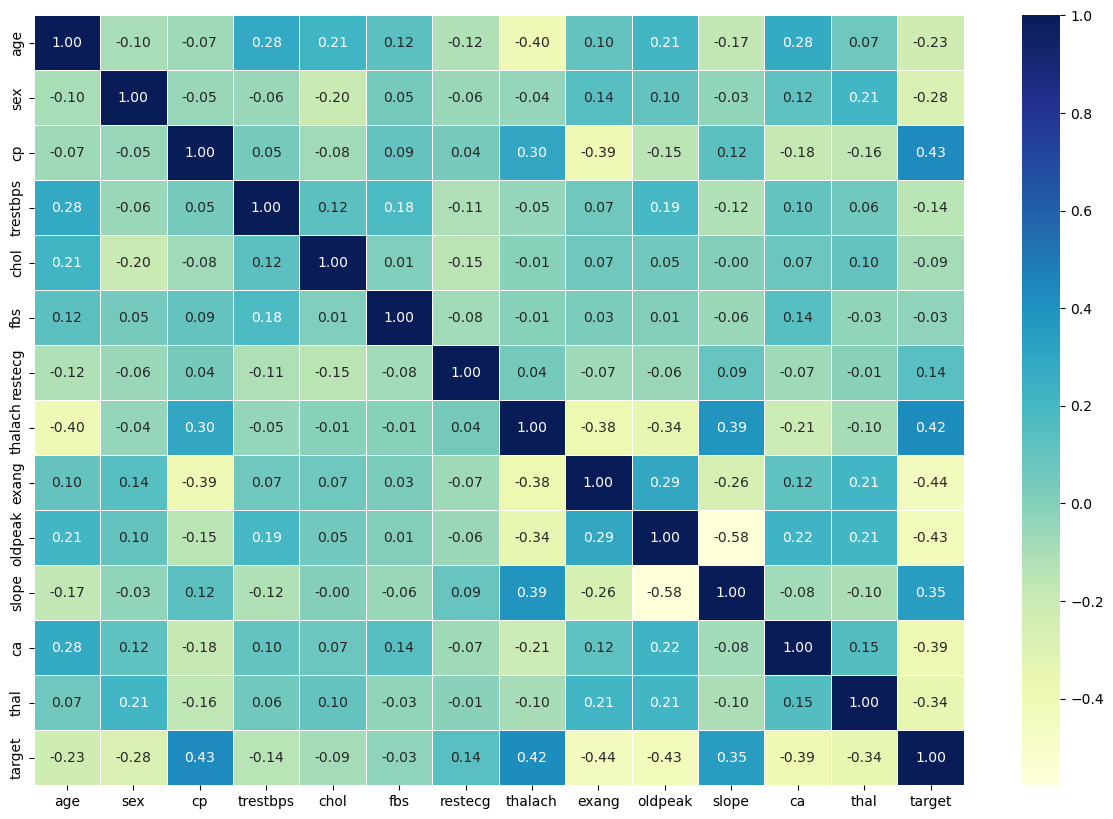

In [20]:
# let's make it look a little prettier
corr_matrix = df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix,
           annot=True,
           linewidths=0.5,
           fmt=".2f",
           cmap="YlGnBu")

In [21]:
# finding missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

> No Missing values

In [22]:
# Detect ourliers

df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

OUTLIER DETECTION REPORT

------------------------------------------------------------
Feature: age
------------------------------------------------------------
Q1            : 47.50
Q3            : 61.00
IQR           : 13.50
Lower Bound   : 27.25
Upper Bound   : 81.25
Outliers Found: 0

------------------------------------------------------------
Feature: trestbps
------------------------------------------------------------
Q1            : 120.00
Q3            : 140.00
IQR           : 20.00
Lower Bound   : 90.00
Upper Bound   : 170.00
Outliers Found: 9

Outlier Values:
     trestbps
8         172
241       174
101       178
260       178
110       180
203       180
266       180
248       192
223       200

------------------------------------------------------------
Feature: chol
------------------------------------------------------------
Q1            : 211.00
Q3            : 274.50
IQR           : 63.50
Lower Bound   : 115.75
Upper Bound   : 369.75
Outliers Found: 5

Outlier Valu

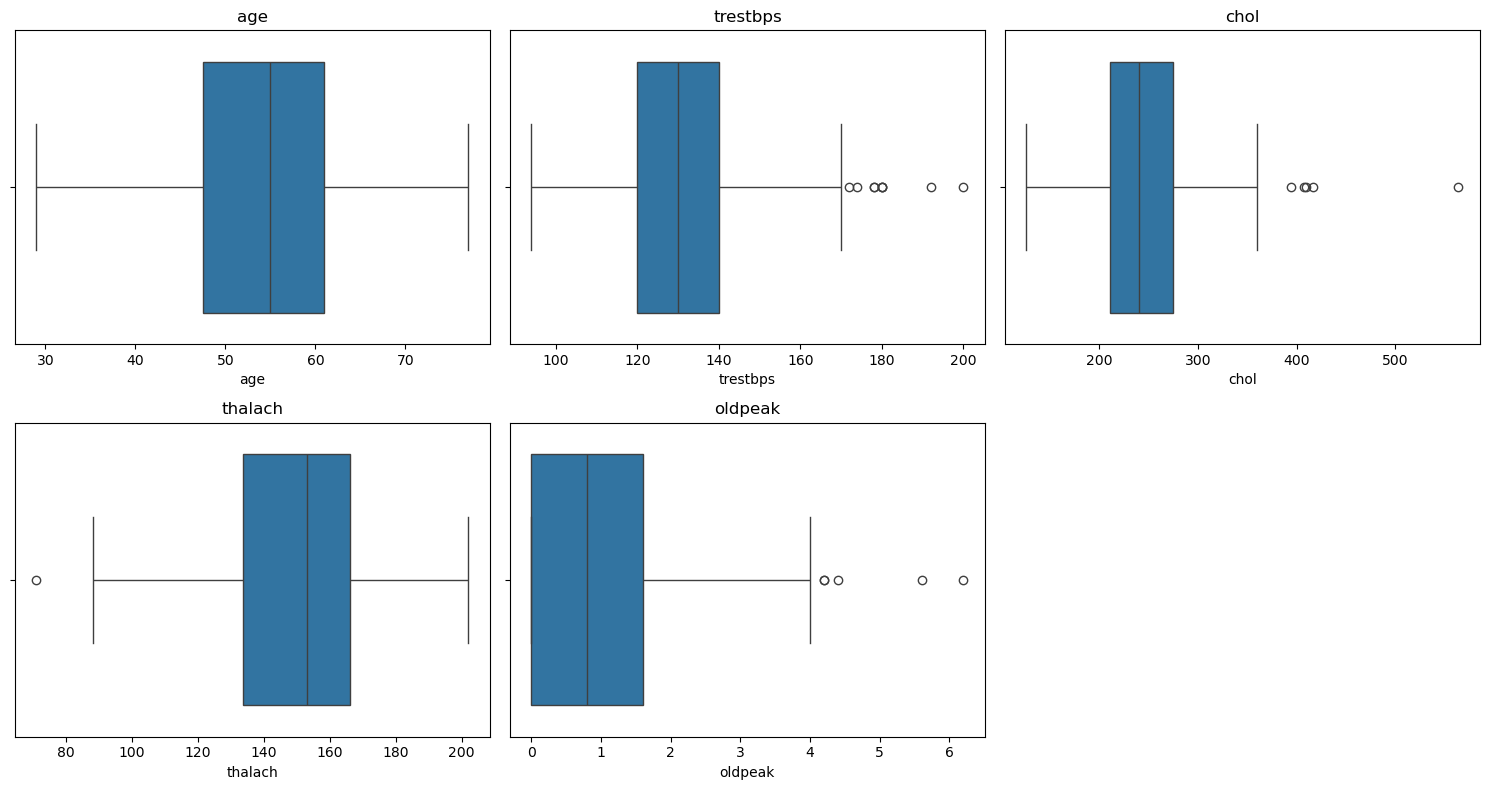

In [23]:
# ==============================
# OUTLIER DETECTION USING IQR
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]

print("="*60)
print("OUTLIER DETECTION REPORT")
print("="*60)

for col in num_cols:

    # Calculate Quartiles
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Calculate Bounds
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Detect Outliers
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    # Print Summary
    print(f"\n{'-'*60}")
    print(f"Feature: {col}")
    print(f"{'-'*60}")
    print(f"Q1            : {Q1:.2f}")
    print(f"Q3            : {Q3:.2f}")
    print(f"IQR           : {IQR:.2f}")
    print(f"Lower Bound   : {lower_bound:.2f}")
    print(f"Upper Bound   : {upper_bound:.2f}")
    print(f"Outliers Found: {len(outliers)}")

    # Display Outlier Values
    if len(outliers) > 0:
        print("\nOutlier Values:")
        print(outliers[[col]].sort_values(by=col))

# ==============================
# BOXPLOTS
# ==============================

plt.figure(figsize=(15, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col])
    plt.title(f"{col}")

plt.tight_layout()
plt.show()

> Outlier detection was performed using the IQR (Interquartile Range) method and boxplots. The features trestbps, chol, thalach, and oldpeak contained potential outliers, while age showed no significant outliers. Since this is a medical dataset, the detected outliers may represent genuine patient conditions rather than data-entry errors; therefore, they were retained for further analysis.

### Enough EDA, let's model

Remember, we do exploratory data analysis (EDA) to start building an intuition of the dataset.

What have we learned so far? 

Aside from our baseline estimate using `sex`, the rest of the data seems to require a bit more exploration before we draw any conclusions.

So what we'll do next is **model driven EDA**, meaning, we'll use machine learning models to drive our next questions.

A few extra things to remember:

* Not every EDA will look the same, what we've seen here is an example of what you could do for structured, tabular dataset.
* You don't necessarily have to do the same plots as we've done here, there are many more ways to visualize data, I encourage you to look at more.

With this being said, let's build some models!

# 🫀 Exploratory Data Analysis — Heart Disease Dataset
### Findings, Insights & Feature Assessment

---

## 1. Dataset Overview

| Property | Value |
|---|---|
| Observations | 303 |
| Features | 14 |
| Target Variable | `target` — Binary (0 = No Disease, 1 = Disease) |
| Missing Values | None |
| Duplicate Records | None |

The dataset is clean, complete, and ready for modelling with no preprocessing overhead.

---

## 2. Target Variable Distribution

> **54% Heart Disease** · **46% No Heart Disease**

The classes are reasonably balanced. Standard classification models can be trained without aggressive resampling techniques (SMOTE, class weighting, etc.).

---

## 3. Key Feature-Level Findings

### 🔵 Age
- Heart disease is more frequent among **middle-aged to older** patients.
- No significant outliers detected.
- **Takeaway:** Age is a meaningful predictor and should be retained as-is.

### 🔵 Gender (`sex`)
- Males dominate the dataset and show **higher heart disease occurrence** than females.
- **Takeaway:** Gender contributes to predictive power — retain as a feature.

### 🔵 Chest Pain Type (`cp`)
- Strongest categorical signal in the dataset.
- Certain `cp` categories show a **disproportionately high** rate of disease.
- **Takeaway:** Likely one of the top features by importance.

### 🔵 Maximum Heart Rate (`thalach`)
- Decreases with age — the age vs. `thalach` relationship is clearly linear.
- Lower `thalach` correlates with higher disease risk.
- **Takeaway:** Strong continuous predictor.

---

## 4. Correlation Summary

| Direction | Features |
|---|---|
| ➕ Positive with Target | `cp` · `thalach` · `slope` |
| ➖ Negative with Target | `oldpeak` · `exang` · `ca` |

Several clinical features show **statistically meaningful relationships** with the target, indicating strong signal for ML models.

---

## 5. Outlier Detection (IQR Method + Boxplots)

| Feature | Outliers Detected |
|---|---|
| `age` | 0 |
| `trestbps` | 9 |
| `chol` | 5 |
| `thalach` | 1 |
| `oldpeak` | 5 |

> ⚠️ **Decision: Retained.** In a medical dataset, extreme values likely reflect genuine patient conditions rather than data-entry errors. Removing them risks discarding clinically relevant cases.

---

## 6. Top Predictive Features

Based on correlation analysis, visualisations, and domain context:

```
cp  ·  thalach  ·  oldpeak  ·  ca  ·  thal  ·  exang
```

These six features will receive priority attention during model evaluation and feature importance analysis.

---

## 7. Conclusion & Next Steps

The dataset is **clean, balanced, and structurally sound** — an ideal candidate for classification.

| Next Phase | Focus |
|---|---|
| Model Building | Logistic Regression · KNN · Random Forest |
| Tuning | Hyperparameter optimisation (GridSearchCV / RandomSearch) |
| Evaluation | Accuracy · Precision · Recall · ROC-AUC |

---